In [5]:
from astroML.datasets import generate_mu_z
import numpy as np
from matplotlib import pyplot as plt
from astroML.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from astroML.linear_model import PolynomialRegression
from astroML.linear_model import BasisFunctionRegression
from astroML.linear_model import NadarayaWatson

(35.0, 50.0)

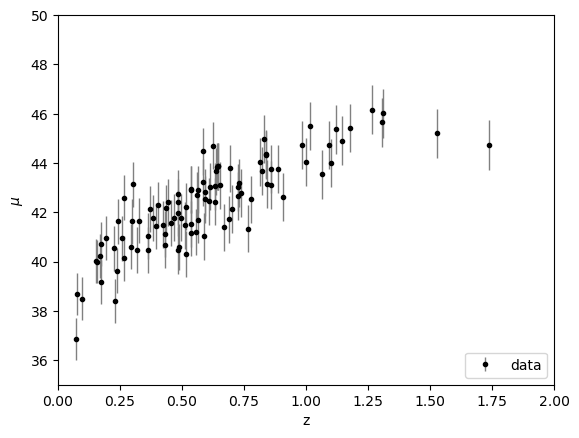

In [7]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1,label="data")
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.legend(loc="lower right")
plt.xlim(0,2)
plt.ylim(35,50)

In [8]:
x = np.linspace(0, 2, 100)

Text(0.5, 1.0, 'linear fit')

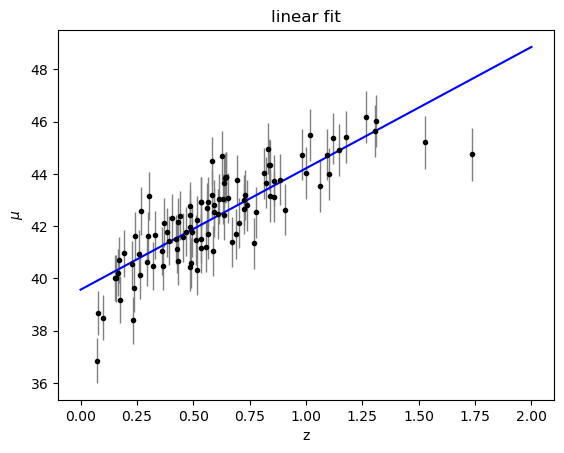

In [3]:
p_lin = np.polyfit(z_sample, mu_sample, 1)
y_lin = np.polyval(p_lin, x)

plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1,label="data")
plt.plot(x, y_lin, "b")
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.title("linear fit")

Text(0.5, 1.0, 'quadratic fit')

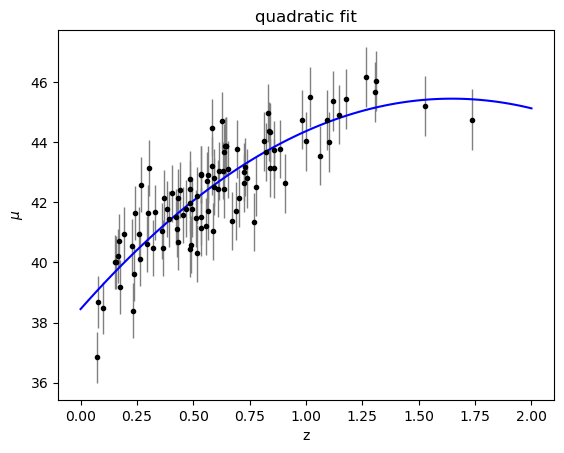

In [4]:
p_2 = np.polyfit(z_sample, mu_sample, 2)
y_2 = np.polyval(p_2, x)

plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1,label="data")
plt.plot(x, y_2, "b")
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.title("quadratic fit")

Text(0.5, 1.0, 'cubic fit')

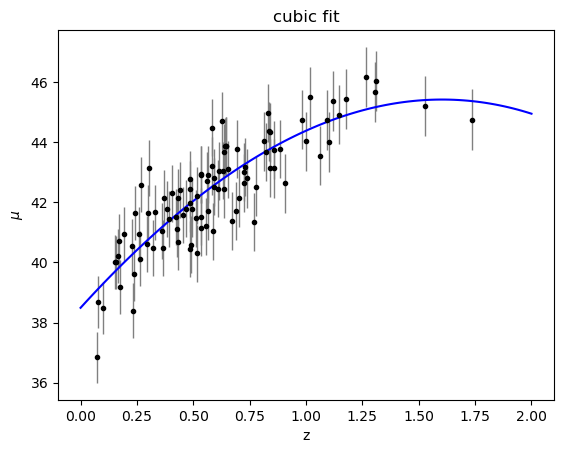

In [5]:
p_3 = np.polyfit(z_sample, mu_sample, 3)
y_3 = np.polyval(p_3, x)

plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1,label="data")
plt.plot(x, y_3, "b")
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.title("cubic fit")

Ok but with astroML

Text(0.5, 1.0, 'linear fit')

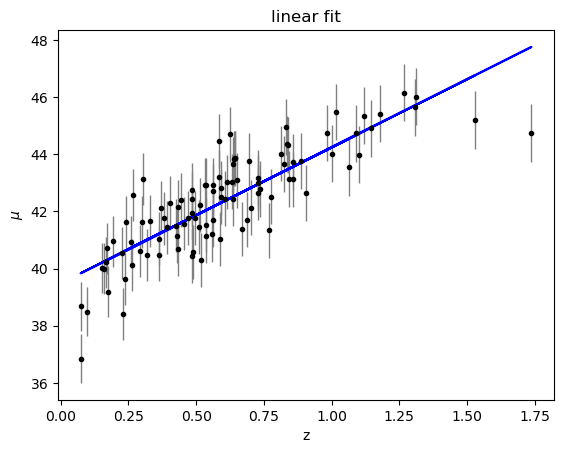

In [26]:
X = z_sample[:, np.newaxis]
y = mu_sample

scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

lin_reg = LinearRegression()
reg = lin_reg.fit(Xscaled, y, dmu)

plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1,label="data")
plt.plot(z_sample, lin_reg.predict(Xscaled), "b")
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.title("linear fit")

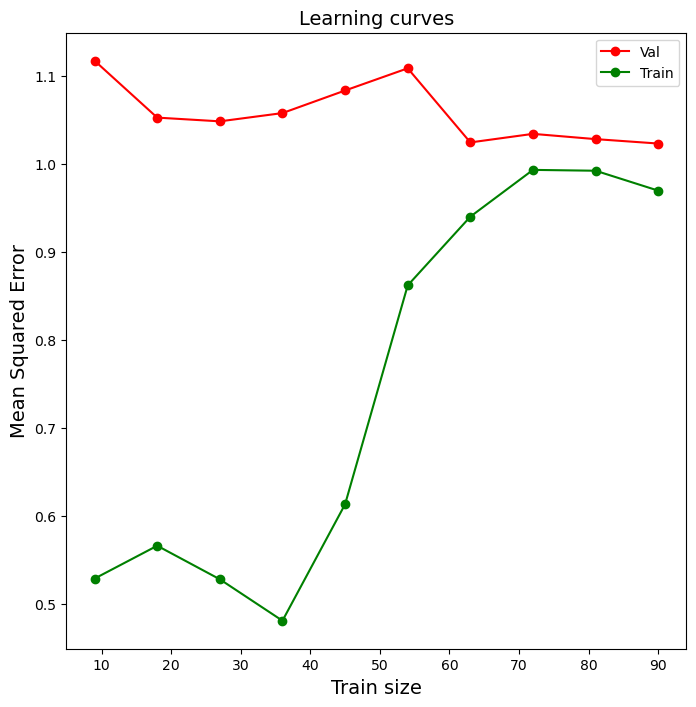

In [27]:
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(lin_reg, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

fig = plt.figure(figsize=(8, 8))

plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size",fontsize=14)
plt.ylabel("Mean Squared Error",fontsize=14)
plt.title('Learning curves',fontsize=14)
plt.legend(loc="best")

Text(0.5, 1.0, 'quadratic fit')

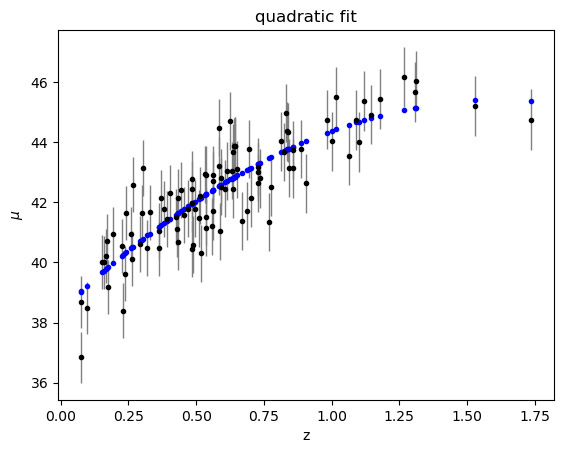

In [42]:
pol_reg = PolynomialRegression(2)
pol_reg.fit(Xscaled, y, dmu)

plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1,label="data")
plt.plot(z_sample, pol_reg.predict(Xscaled), ".b")
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.title("quadratic fit")

Text(0.5, 1.0, 'quadratic fit')

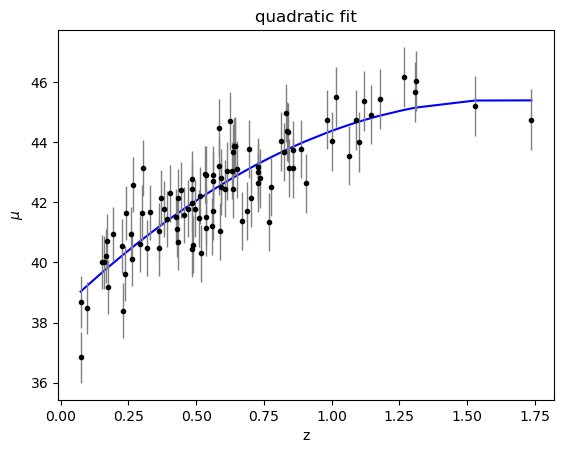

In [55]:
points = np.array([pol_reg.predict(Xscaled), z_sample])
points.sort(axis=1)
plt.plot(points[1], points[0], "b")

plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1,label="data")
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.title("quadratic fit")

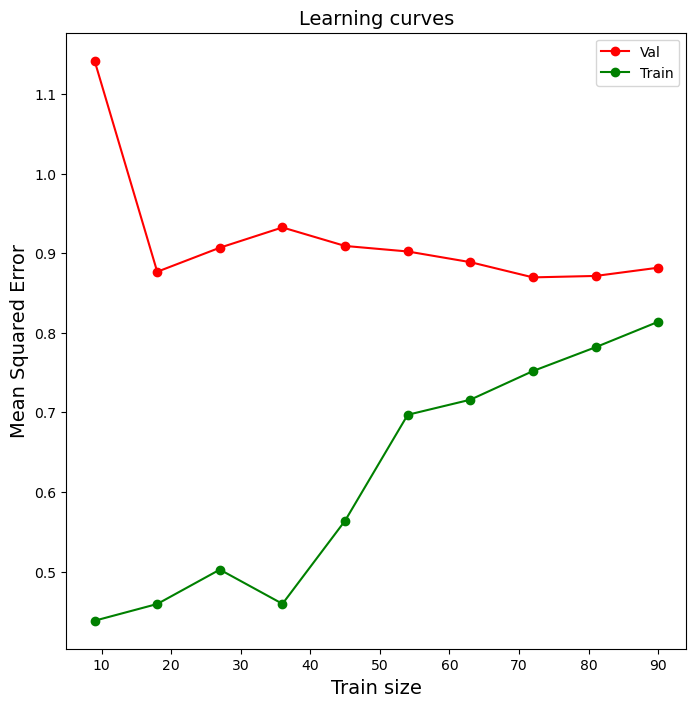

In [44]:
train_sizes, train_scores_polreg, test_scores_polreg = \
    learning_curve(pol_reg, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

fig = plt.figure(figsize=(8, 8))

plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size",fontsize=14)
plt.ylabel("Mean Squared Error",fontsize=14)
plt.title('Learning curves',fontsize=14)
plt.legend(loc="best")